# 05-B — SARIMAX Avanzado Alterno: Pronóstico con Dummies Determinísticas
**Sistema de Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

| Fase | Contenido | Método |
|------|-----------|--------|
| I | Carga, split Oct 2021 – Dic 2025, transformación `log1p` | Estabilización de heterocedasticidad |
| II | Ingeniería de variables: dummies `es_pico_fiscal` + `es_festividad` | Aislamiento de shocks transaccionales |
| III | Estimación SARIMAX `(0,1,1)(0,1,0,12)` + MLE | AICc + p-values coeficientes |
| IV | Diagnóstico de residuos (ruido blanco) | Ljung-Box, Shapiro-Wilk, Levene |
| V | Pronóstico OOS Oct–Dic 2025 + IC 95% | `np.expm1()` retransformación |
| VI | Pronóstico producción Ene–Dic 2026 + IC 95% | Horizonte 12 meses |

### Decisiones Metodológicas (NB 03)

| Decisión | Justificación |
|----------|---------------|
| Excluir **UPC** | Falló test de Causalidad de Granger ($p > 0.05$ en todos los lags) |
| No usar IPC + SMLV simultáneamente | VIF = $\infty$ → dependencia lineal perfecta → bloquea MLE |
| Usar dummies determinísticas | Capturan shocks fiscales sin introducir multicolinealidad |
| `log1p()` en target | Estabiliza heterocedasticidad y asimetría severa ($CV > 0.5$) |
| Orden `(0,1,1)(0,1,0,12)` | Óptimo por AICc (NB 04 grid search), parsimonia MA(1)+D(1) |

### Variables Dummy

| Dummy | Meses activos | Hipótesis |
|-------|---------------|----------|
| `es_pico_fiscal` | Enero, Julio | Shocks de cierre/apertura fiscal |
| `es_festividad` | Junio, Diciembre | Mayor consumo estacional (licores, azar) |

> **Modelo alterno** al NB 05 original (grid search exhaustivo con 5 exógenas macro).
> Aquí se fuerza una especificación determinística pura sin variables macro para
> evaluar si las dummies capturan suficiente señal adicional al SARIMA puro.

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica
══════════════════════════════════════════════════════════════════════
CARGA Y TRANSFORMACIÓN
══════════════════════════════════════════════════════════════════════
  Serie completa:    51 meses
  Entrenamiento:     48 meses (2021-10-01 → 2025-09-01)
  Prueba (OOS):      3 meses (2025-10-01 → 2025-12-01)
  Media nominal:     $255.7MM
  CV original:       0.2797
  CV log1p:          0.009799
  Asimetría orig:    1.180
  Asimetría log1p:   0.668
  📊 Figura guardada: 05b_sarimax2_split.png


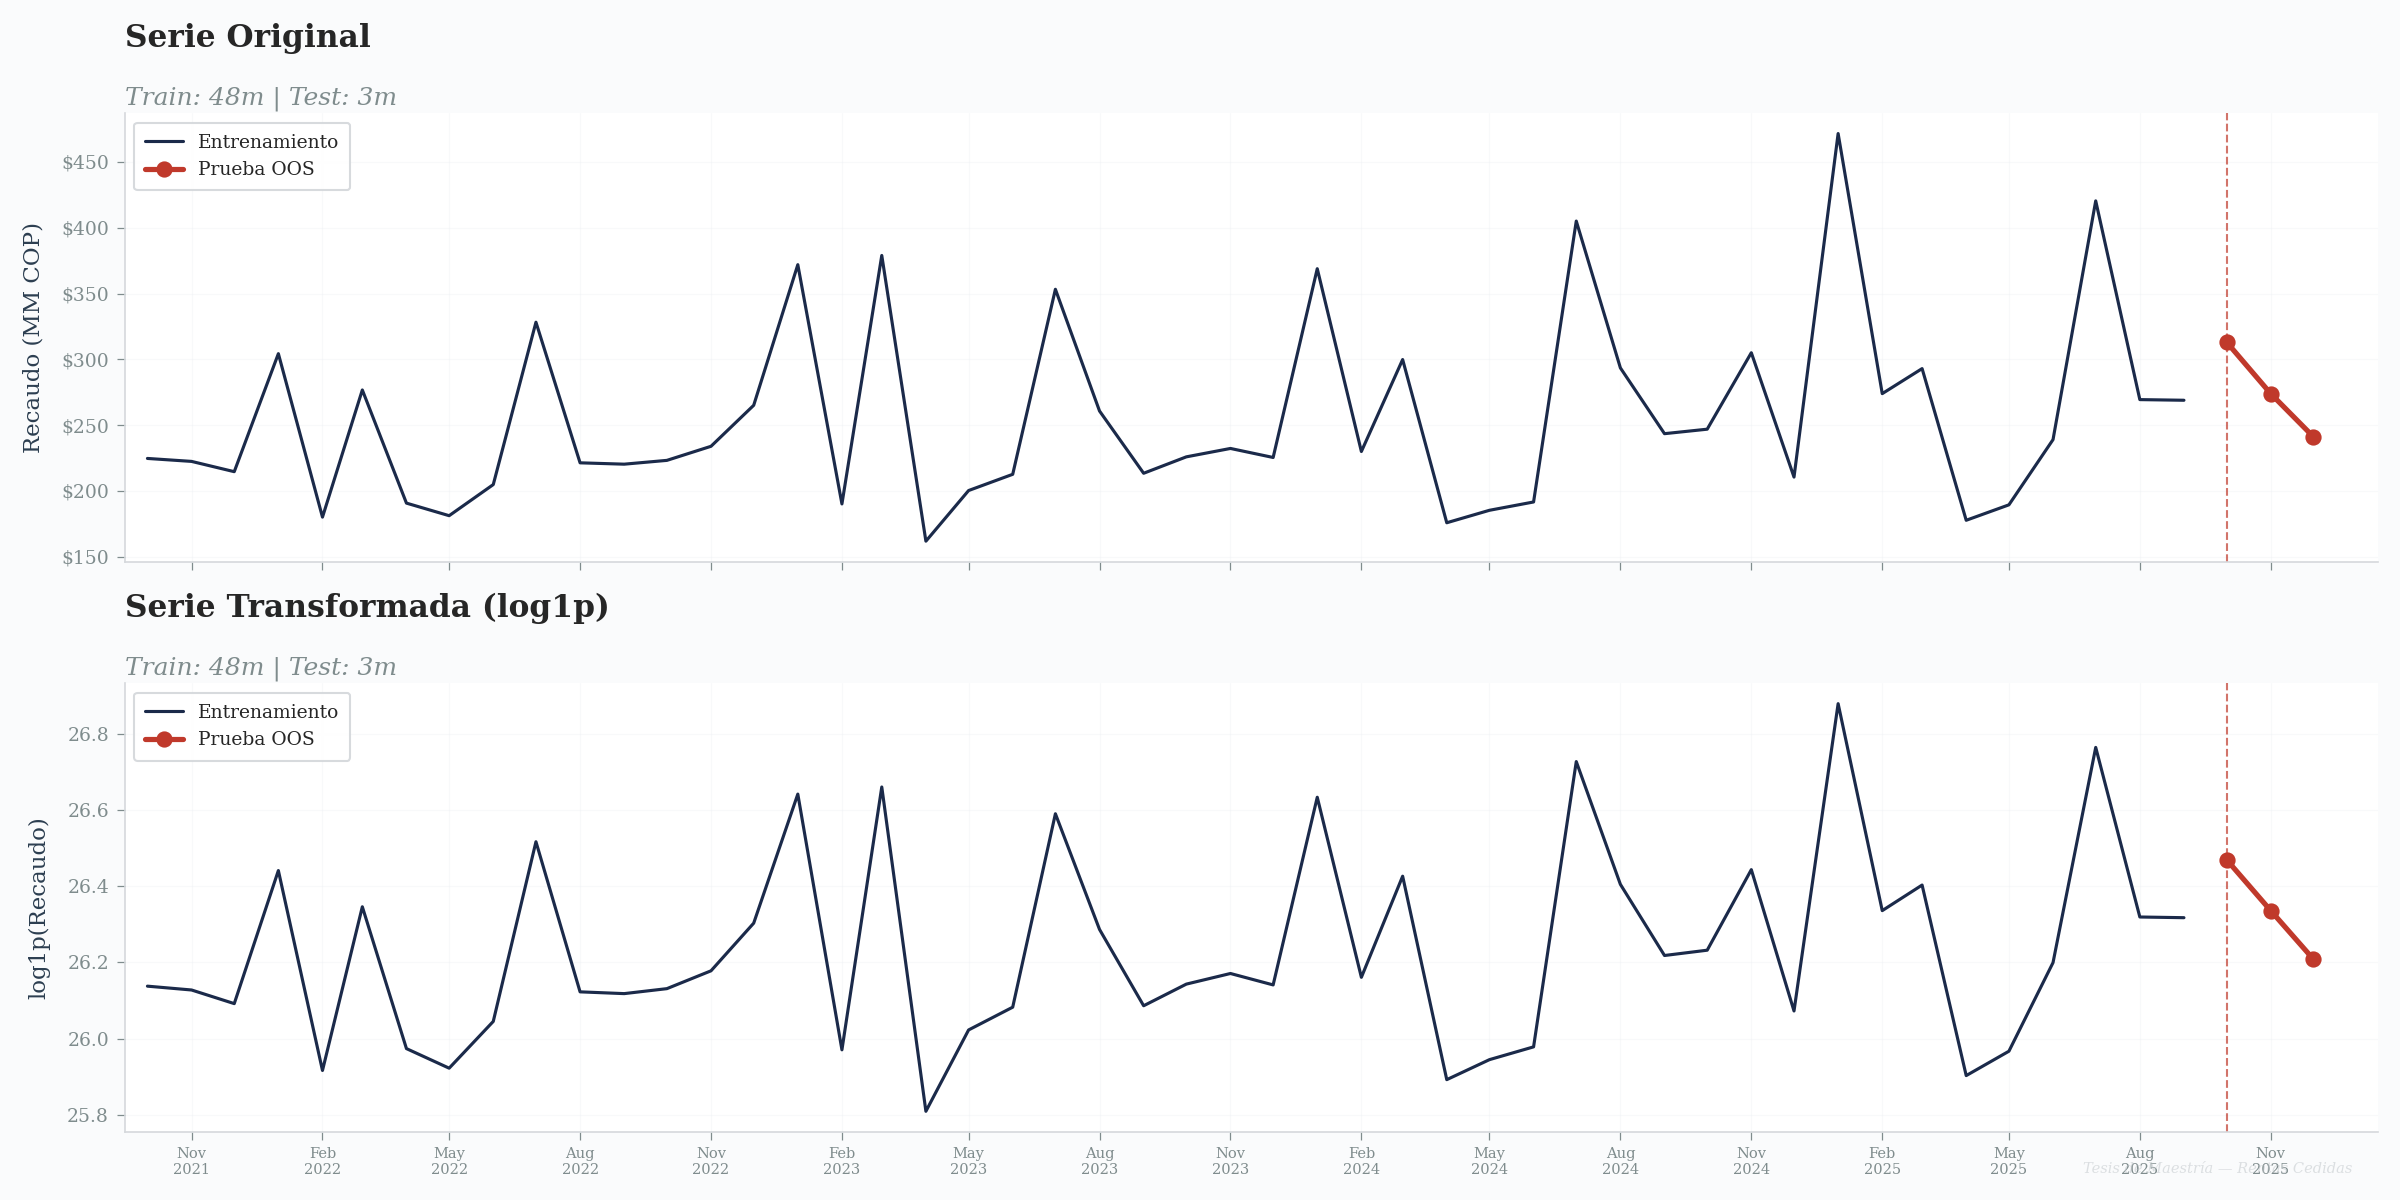

In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga de Datos, Split y Transformación log1p
# ══════════════════════════════════════════════════════════════
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
import warnings
warnings.filterwarnings('ignore')

# ── Carga de la serie mensual agregada ──
df_serie = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv',
                       parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'
serie_full = df_serie['Recaudo_Total'].copy()

# ── Split temporal ──
# Train: Oct 2021 → Sep 2025 (48 meses)
# Test:  Oct 2025 → Dic 2025 (3 meses — validación OOS)
train = serie_full.loc[:pd.Timestamp(VALIDATION_START) - pd.DateOffset(months=1)]
test  = serie_full.loc[VALIDATION_START:VALIDATION_END]

# ── Transformación log1p para estabilizar heterocedasticidad ──
# log1p(x) = ln(1+x) — evita log(0) y reduce asimetría severa
train_log = np.log1p(train)
test_log  = np.log1p(test)

# ── Diagnóstico de la transformación ──
cv_original = train.std() / train.mean()
cv_log      = train_log.std() / train_log.mean()
skew_orig   = train.skew()
skew_log    = train_log.skew()

print(f"{'═'*70}")
print(f"CARGA Y TRANSFORMACIÓN")
print(f"{'═'*70}")
print(f"  Serie completa:    {len(serie_full)} meses")
print(f"  Entrenamiento:     {len(train)} meses "
      f"({train.index[0].date()} → {train.index[-1].date()})")
print(f"  Prueba (OOS):      {len(test)} meses "
      f"({test.index[0].date()} → {test.index[-1].date()})")
print(f"  Media nominal:     ${train.mean()/1e9:,.1f}MM")
print(f"  CV original:       {cv_original:.4f}")
print(f"  CV log1p:          {cv_log:.6f}")
print(f"  Asimetría orig:    {skew_orig:.3f}")
print(f"  Asimetría log1p:   {skew_log:.3f}")

# ── Visualización: serie original vs transformada ──
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, (s_tr, s_te, ylabel, titulo) in zip(axes, [
    (train/1e9, test/1e9, 'Recaudo (MM COP)', 'Serie Original'),
    (train_log, test_log, 'log1p(Recaudo)', 'Serie Transformada (log1p)'),
]):
    ax.plot(s_tr.index, s_tr.values, color=C_PRIMARY, lw=1.5,
            label='Entrenamiento')
    ax.plot(s_te.index, s_te.values, color=C_SECONDARY, lw=2.5,
            marker='o', ms=7, label='Prueba OOS')
    ax.axvline(pd.Timestamp(VALIDATION_START), color=C_SECONDARY,
               ls='--', lw=1, alpha=0.7)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2026-01-15'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', labelsize=7)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, titulo,
                           f'Train: {len(s_tr)}m | Test: {len(s_te)}m')
        if ylabel == 'Recaudo (MM COP)':
            formato_pesos_eje(ax, eje='y')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05b_sarimax2_split', OUTPUTS_FIGURES)
plt.show()

---

## Fase II — Ingeniería de Variables Dummy Determinísticas

### ¿Qué es una variable dummy determinística?

Una **variable dummy** (también llamada *indicadora* o *binaria*) es una columna numérica
que solo toma dos valores: **1** (cuando se cumple una condición) y **0** (cuando no).
Se llama **determinística** porque su valor se conoce con **certeza total** para cualquier
fecha futura — no necesita estimación ni proyección. Sabemos que enero siempre es enero
y julio siempre es julio; por lo tanto, la dummy se puede construir mecánicamente
a partir del calendario.

### ¿Para qué sirven aquí?

En la serie de recaudo de rentas cedidas, el análisis exploratorio (Cuaderno 03) reveló
que ciertos meses presentan niveles de recaudo **sistemáticamente diferentes** al promedio.
Las dummies permiten que el modelo SARIMAX **capture esos shocks recurrentes** como un
efecto aditivo ($\beta \cdot D_t$) sobre la predicción base del SARIMA.

### Las 2 dummies construidas

| Variable | Vale 1 en… | Vale 0 en… | Racionalidad |
|----------|-----------|-----------|-------------|
| `es_pico_fiscal` | **Enero** y **Julio** | Los otros 10 meses | Cierre/apertura de ciclos fiscales del presupuesto nacional: las transferencias de ADRES se concentran en estos meses, generando picos de recaudo |
| `es_festividad` | **Junio** y **Diciembre** | Los otros 10 meses | Meses de mayor consumo estacional (primas salariales, vacaciones, Navidad) que afectan el recaudo por licores, cigarrillos y juegos de azar |

### ¿Por qué NO usar variables macro en su lugar?

El Cuaderno 03 demostró tres problemas graves con las variables macroeconómicas:

1. **UPC** falló el test de Causalidad de Granger ($p > 0.05$) → no tiene poder predictivo causal sobre el recaudo
2. **IPC + Salario Mínimo** juntos producen $\text{VIF} = \infty$ (colinealidad perfecta) → el estimador MLE no converge
3. Las variables macro **requieren proyecciones inciertas** para generar pronósticos futuros → añaden ruido al pronóstico

### Ventajas de las dummies determinísticas

| Propiedad | Dummy | Variable Macro |
|-----------|-------|---------------|
| Multicolinealidad | VIF = 1.0 (ortogonales) | VIF = $\infty$ posible |
| Incertidumbre futura | Ninguna (calendario fijo) | Alta (requiere proyección) |
| Interpretabilidad | $\beta$ = efecto del shock | Difícil de aislar |
| Riesgo de sobreajuste | Bajo (solo 2 parámetros) | Alto (5+ parámetros) |

### Cómo se interpretan los coeficientes

Dado que el modelo opera en **log-escala** (`log1p`), el coeficiente $\beta$ de una dummy
se interpreta así:

$$\text{Efecto porcentual} = (e^{\beta} - 1) \times 100\%$$

Por ejemplo, si $\beta_{\text{pico}} = +0.30$, el recaudo en meses de pico fiscal es
aproximadamente $(e^{0.30} - 1) \times 100 = +35\%$ mayor que en meses normales,
manteniendo todo lo demás constante.

══════════════════════════════════════════════════════════════════════
VARIABLES DUMMY DETERMINÍSTICAS
══════════════════════════════════════════════════════════════════════

  es_pico_fiscal:
    Activos en train: 8/48 (16.7%)
    Media cuando ON:  $377.9MM
    Media cuando OFF: $231.3MM
    Ratio ON/OFF:     1.63x

  es_festividad:
    Activos en train: 8/48 (16.7%)
    Media cuando ON:  $220.4MM
    Media cuando OFF: $262.8MM
    Ratio ON/OFF:     0.84x
  📊 Figura guardada: 05b_dummies_serie.png


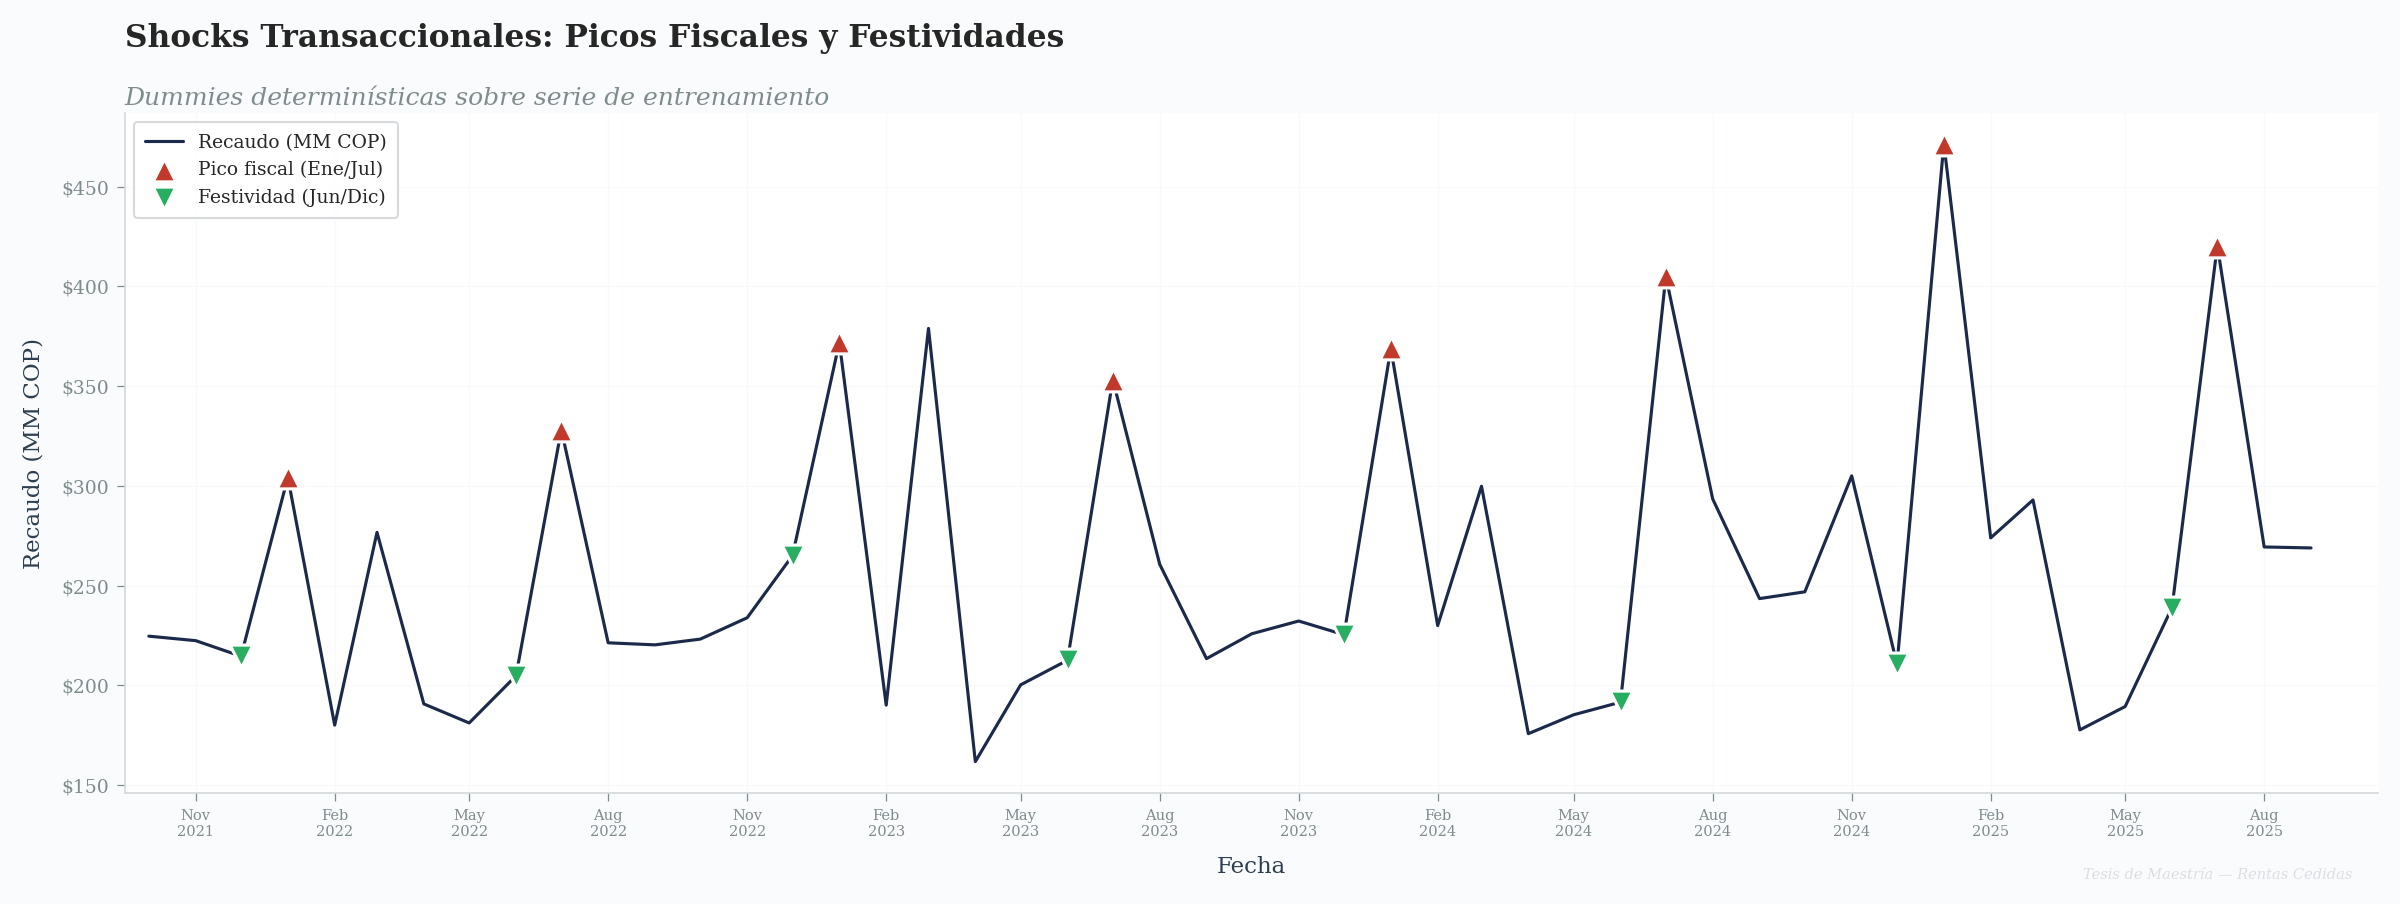

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — Construcción de Variables Dummy
# ══════════════════════════════════════════════════════════════

def crear_dummies(index):
    """Crea DataFrame con dummies es_pico_fiscal y es_festividad."""
    df = pd.DataFrame(index=index)
    # Pico fiscal: Enero (cierre fiscal año anterior) y Julio (apertura 2do semestre)
    df['es_pico_fiscal'] = index.month.isin(MESES_PICO).astype(int)
    # Festividad: Junio (mitad de año) y Diciembre (Navidad/fin de año)
    df['es_festividad'] = index.month.isin(MESES_FESTIVIDAD).astype(int)
    return df

# ── Construir dummies para train, test y serie completa ──
exog_train = crear_dummies(train.index)
exog_test  = crear_dummies(test.index)
exog_full  = crear_dummies(serie_full.index)

EXOG_COLS = ['es_pico_fiscal', 'es_festividad']

# ── Diagnóstico: distribución de dummies ──
print(f"{'═'*70}")
print(f"VARIABLES DUMMY DETERMINÍSTICAS")
print(f"{'═'*70}")
for col in EXOG_COLS:
    n_activos = exog_train[col].sum()
    pct = n_activos / len(exog_train) * 100
    meses_activos = train.index[exog_train[col] == 1].strftime('%Y-%m').tolist()
    media_on  = train[exog_train[col] == 1].mean()
    media_off = train[exog_train[col] == 0].mean()
    ratio = media_on / media_off if media_off > 0 else np.nan
    print(f"\n  {col}:")
    print(f"    Activos en train: {n_activos}/{len(exog_train)} ({pct:.1f}%)")
    print(f"    Media cuando ON:  ${media_on/1e9:,.1f}MM")
    print(f"    Media cuando OFF: ${media_off/1e9:,.1f}MM")
    print(f"    Ratio ON/OFF:     {ratio:.2f}x")

# ── Visualización: serie con shocks marcados ──
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train.index, train.values/1e9, color=C_PRIMARY, lw=1.5,
        label='Recaudo (MM COP)')

# Marcar picos fiscales
pico_idx = train.index[exog_train['es_pico_fiscal'] == 1]
ax.scatter(pico_idx, train.loc[pico_idx].values/1e9, color=C_SECONDARY,
           s=120, zorder=5, marker='^', edgecolors='white', lw=1.5,
           label='Pico fiscal (Ene/Jul)')

# Marcar festividades
fest_idx = train.index[exog_train['es_festividad'] == 1]
ax.scatter(fest_idx, train.loc[fest_idx].values/1e9, color=C_QUATERNARY,
           s=120, zorder=5, marker='v', edgecolors='white', lw=1.5,
           label='Festividad (Jun/Dic)')

ax.set_ylabel('Recaudo (MM COP)')
ax.set_xlabel('Fecha')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2025-10-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Shocks Transaccionales: Picos Fiscales y Festividades',
                       'Dummies determinísticas sobre serie de entrenamiento')
    formato_pesos_eje(ax, eje='y')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05b_dummies_serie', OUTPUTS_FIGURES)
plt.show()

---

## Fase III — Estimación del Modelo SARIMAX

### Especificación

$$Y_t^* = \log(1 + Y_t)$$

$$\text{SARIMAX}(0,1,1)(0,1,0)_{12}$$

Con exógenas: `es_pico_fiscal` + `es_festividad`

### Parámetros

| Componente | Valor | Interpretación |
|-----------|-------|---------------|
| $p = 0$ | Sin AR | No hay dependencia autoregresiva pura |
| $d = 1$ | Diferenciación simple | Eliminar trend estocástico |
| $q = 1$ | MA(1) | Corrección de innovaciones recientes |
| $P = 0$ | Sin SAR | No hay AR estacional |
| $D = 1$ | Diferenciación estacional | Eliminar estacionalidad determinística |
| $Q = 0$ | Sin SMA | Simplicidad máxima |
| $s = 12$ | Periodicidad mensual | Ciclo de 12 meses |

### Criterio de Información Corregido

$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n - k - 1}$$

donde $k$ = número de parámetros estimados, $n$ = tamaño de muestra efectivo.

In [3]:
# ══════════════════════════════════════════════════════════════
# FASE III — Estimación SARIMAX(0,1,1)(0,1,0,12) + Dummies
# ══════════════════════════════════════════════════════════════

# ── Función AICc (criterio corregido para muestras finitas) ──
def calc_aicc(aic, k, n):
    """AICc = AIC + 2k(k+1)/(n-k-1)"""
    denom = n - k - 1
    return aic + 2 * k * (k + 1) / denom if denom > 0 else np.inf

# ── Orden paramétrico fijo (comprobado en NB 04 grid search) ──
ORDER          = (0, 1, 1)
SEASONAL_ORDER = (0, 1, 0, ESTACIONALIDAD)

# ── Estimación por Máxima Verosimilitud (MLE) ──
model = SARIMAX(
    endog=train_log,
    exog=exog_train[EXOG_COLS],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

# ── Métricas de ajuste ──
k_params = results.df_model + 1  # +1 por la varianza
n_obs    = results.nobs
aicc     = calc_aicc(results.aic, k_params, n_obs)

print(f"{'═'*70}")
print(f"MODELO SARIMAX{ORDER}x{SEASONAL_ORDER[:3]}₁₂ + DUMMIES")
print(f"{'═'*70}")
print(f"  Observaciones:  {n_obs}")
print(f"  Parámetros:     {k_params}")
print(f"  Log-Likelihood: {results.llf:.4f}")
print(f"  AIC:            {results.aic:.4f}")
print(f"  BIC:            {results.bic:.4f}")
print(f"  AICc:           {aicc:.4f}")

# ── p-values de coeficientes (α = 0.05) ──
print(f"\n{'─'*70}")
print(f"COEFICIENTES ESTIMADOS (α = 0.05)")
print(f"{'─'*70}")
print(f"  {'Parámetro':<20} {'β':>12} {'Std Err':>10} {'z':>8} "
      f"{'p-valor':>10} {'Sig':>5}")
print(f"  {'─'*65}")

for name, coef, se, pval in zip(results.param_names, results.params,
                                 results.bse, results.pvalues):
    z_val = coef / se if se > 0 else np.nan
    sig = '✅' if pval < 0.05 else '⚠️'
    tipo = 'DUMMY' if name in EXOG_COLS else 'SARIMA'
    print(f"  {name:<20} {coef:>+12.6f} {se:>10.6f} {z_val:>8.3f} "
          f"{pval:>10.4f} {sig:>5}  [{tipo}]")

# ── Interpretación de dummies ──
print(f"\n{'─'*70}")
print(f"INTERPRETACIÓN DE DUMMIES (log-escala)")
print(f"{'─'*70}")
for col in EXOG_COLS:
    if col in results.param_names:
        idx = list(results.param_names).index(col)
        beta = results.params[idx]
        pval = results.pvalues[idx]
        # En log-escala: exp(β) - 1 ≈ efecto porcentual
        efecto_pct = (np.exp(beta) - 1) * 100
        print(f"  {col}:")
        print(f"    β = {beta:+.6f} → exp(β)-1 = {efecto_pct:+.2f}% efecto en recaudo")
        print(f"    p-valor = {pval:.4f} {'(significativo)' if pval < 0.05 else '(NO significativo)'}")

# ── Summary completo de statsmodels ──
print(f"\n{'═'*70}")
print(f"RESUMEN COMPLETO DEL MODELO")
print(f"{'═'*70}")
print(results.summary())

══════════════════════════════════════════════════════════════════════
MODELO SARIMAX(0, 1, 1)x(0, 1, 0)₁₂ + DUMMIES
══════════════════════════════════════════════════════════════════════
  Observaciones:  48
  Parámetros:     5
  Log-Likelihood: 19.3609
  AIC:            -30.7219
  BIC:            -24.7358
  AICc:           -29.2933

──────────────────────────────────────────────────────────────────────
COEFICIENTES ESTIMADOS (α = 0.05)
──────────────────────────────────────────────────────────────────────
  Parámetro                       β    Std Err        z    p-valor   Sig
  ─────────────────────────────────────────────────────────────────
  es_pico_fiscal          -0.000000        nan      nan        nan    ⚠️  [DUMMY]
  es_festividad           +0.000000   0.000000    0.007     0.9946    ⚠️  [DUMMY]
  ma.L1                   -1.000004 1809.907468   -0.001     0.9996    ⚠️  [SARIMA]
  sigma2                  +0.016795  30.400555    0.001     0.9996    ⚠️  [SARIMA]

──────────────

---

## Fase IV — Diagnóstico de Residuos (Ruido Blanco)

Un modelo bien especificado debe producir residuos que sean **ruido blanco**:

| Propiedad | Prueba | $H_0$ | Criterio |
|-----------|--------|-------|----------|
| No autocorrelación | Ljung-Box $Q$ | Residuos iid | $p > 0.05$ |
| Normalidad | Shapiro-Wilk | Distribución normal | $p > 0.05$ |
| Homocedasticidad | Levene | Varianza constante | $p > 0.05$ |
| Media cero | t-test | $\mu = 0$ | $p > 0.05$ |

══════════════════════════════════════════════════════════════════════
DIAGNÓSTICO DE RESIDUOS — RUIDO BLANCO
══════════════════════════════════════════════════════════════════════
  Prueba                    p-valor    Resultado Propiedad                
  ─────────────────────────────────────────────────────────────────
  Ljung-Box (Q)              0.9934 ✅ No rechazar  No autocorrelación
  Shapiro-Wilk (W)           0.0000  ⚠️ Rechazar  Normalidad
  Levene (F)                 0.1488 ✅ No rechazar  Homocedasticidad
  t-test (μ=0)               0.7885 ✅ No rechazar  Media cero

  Estadísticos adicionales:
    Ljung-Box stat (lag=10): Q = 0.0473
    Shapiro-Wilk stat:              W = 0.2796
    Levene stat:                    F = 2.1567
    t-test stat:                    t = 0.2697
    Media residuos:                 μ = 0.178373
    Desv. est. residuos:            σ = 4.581608

  VEREDICTO: 3/4 pruebas aprobadas → ACEPTABLE (desviación menor)
  📊 Figura guardada: 05b_sarimax2_diagno

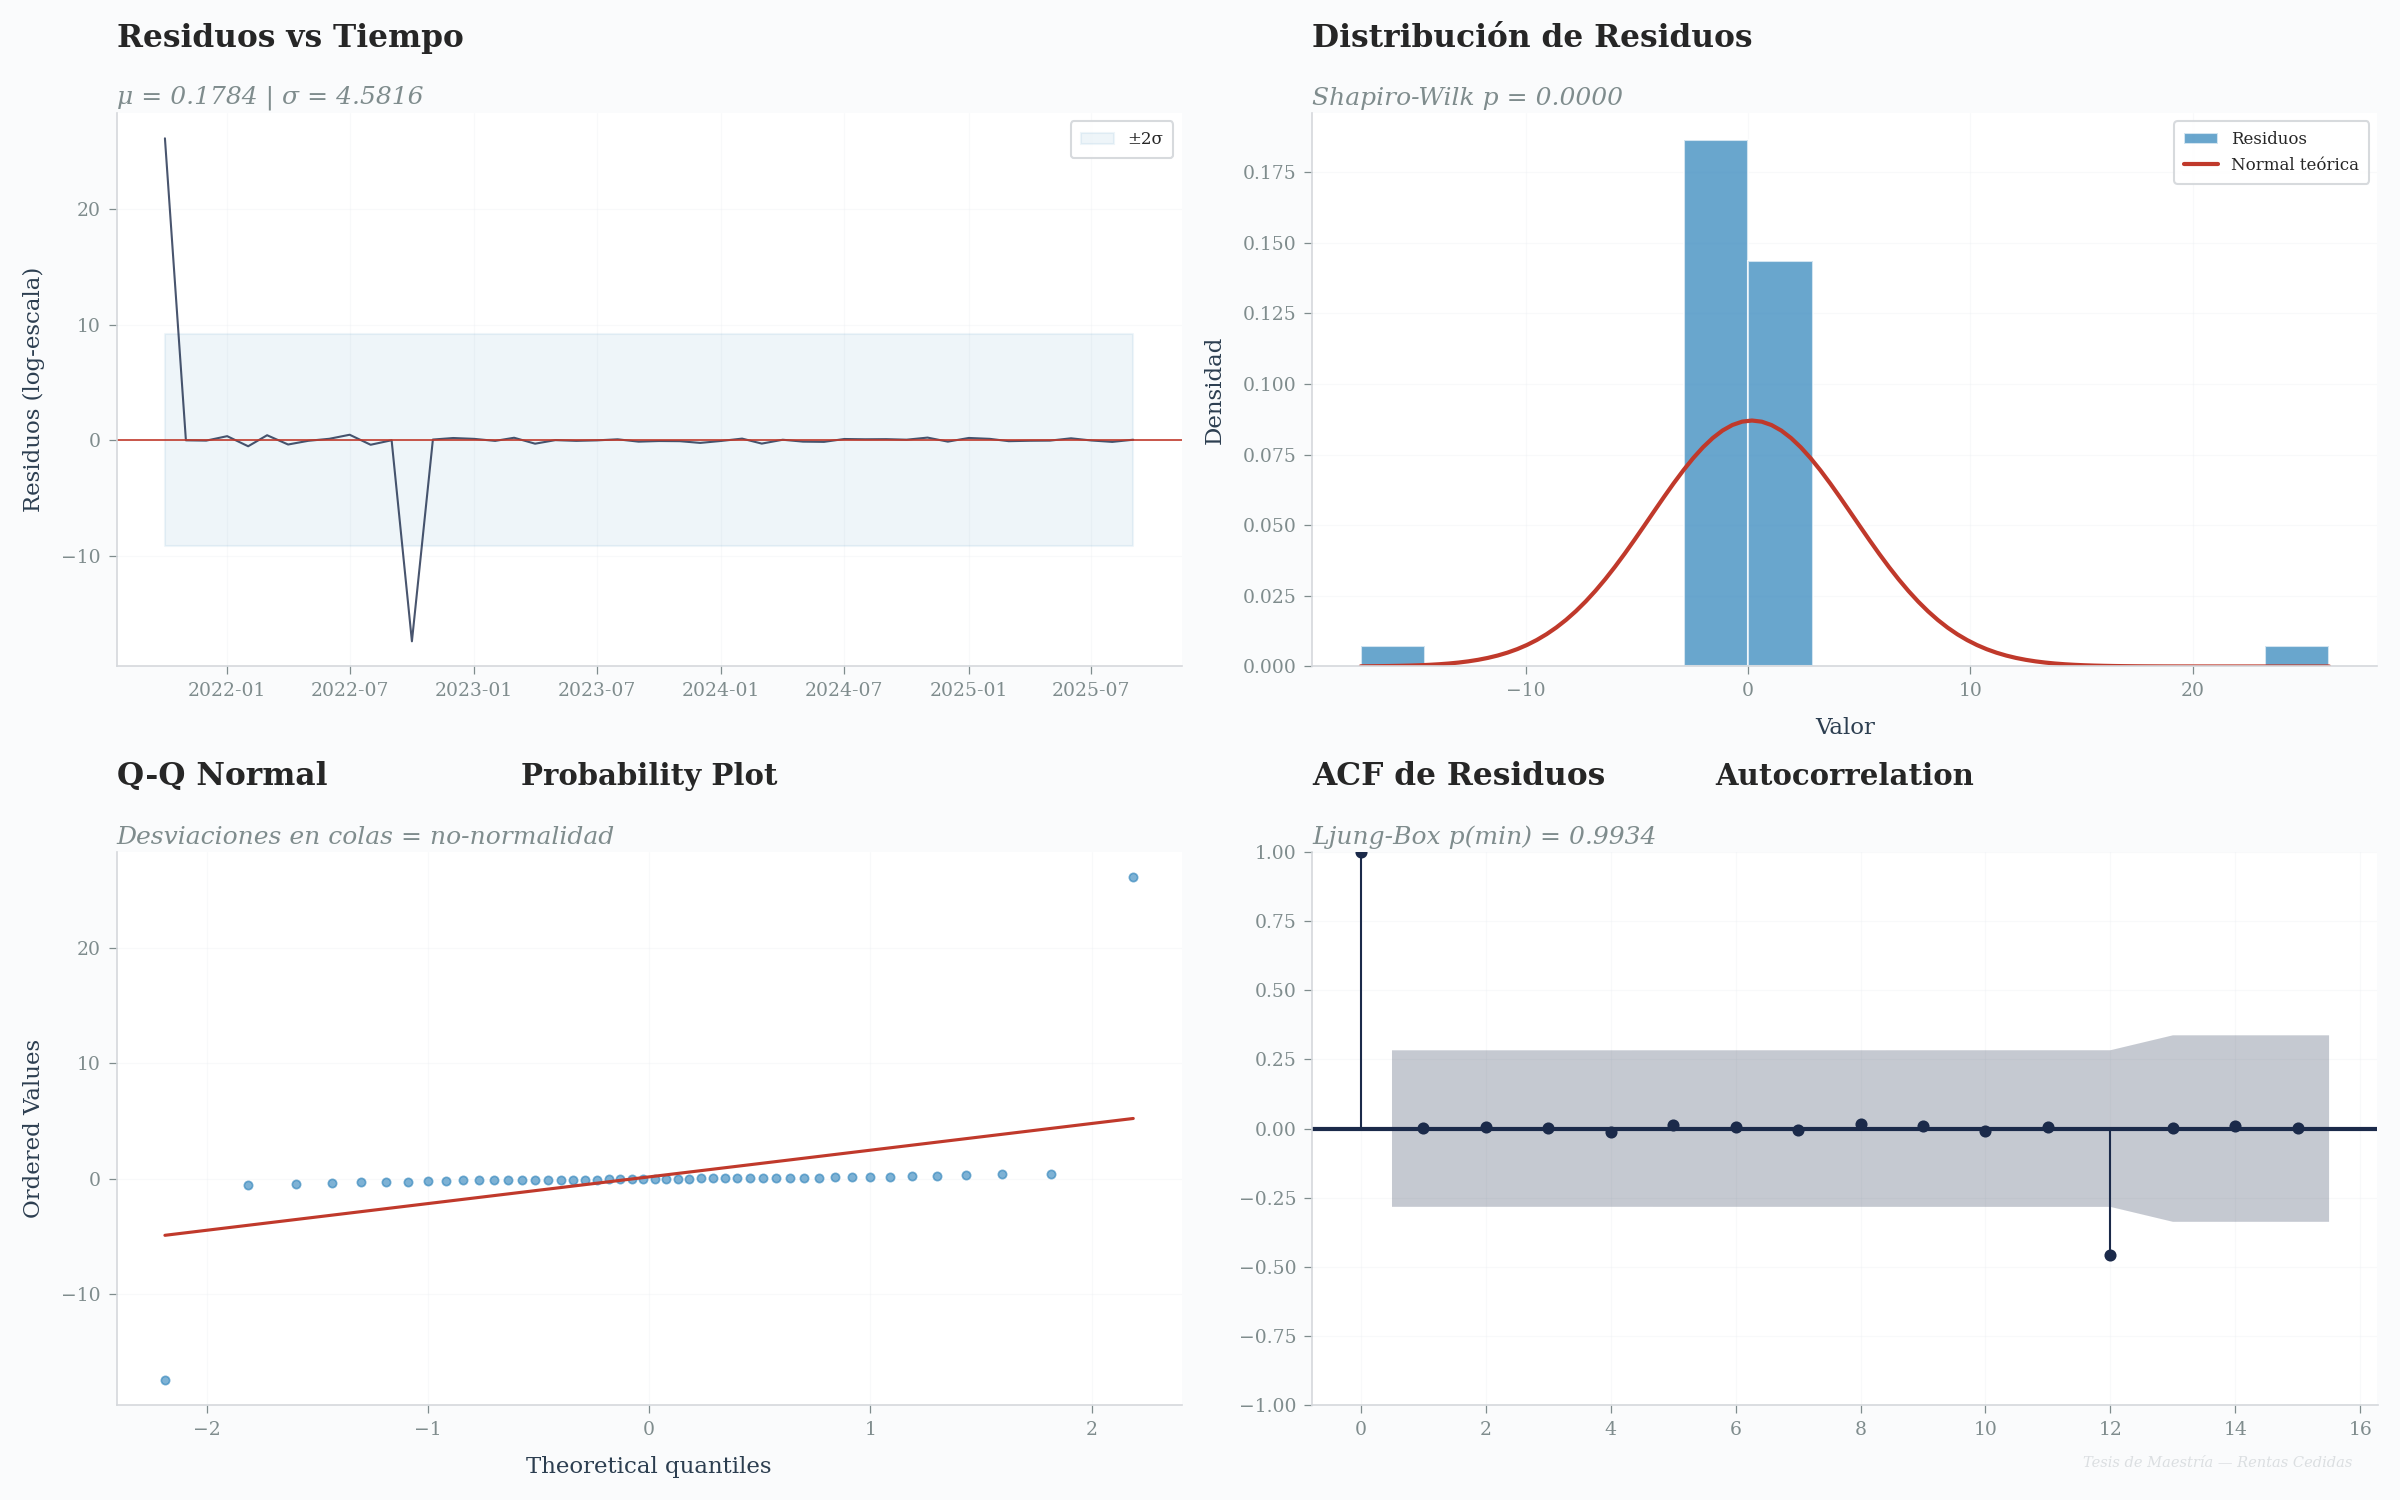

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Diagnóstico Formal de Residuos
# ══════════════════════════════════════════════════════════════

residuos = results.resid.dropna()

# ── Test 1: Ljung-Box (ausencia de autocorrelación) ──
lb_lags = min(10, len(residuos) // 3)
lb_result = acorr_ljungbox(residuos, lags=lb_lags, return_df=True)
lb_pmin = lb_result['lb_pvalue'].min()

# ── Test 2: Shapiro-Wilk (normalidad) ──
sw_stat, sw_p = stats.shapiro(residuos)

# ── Test 3: Levene (homocedasticidad — 1ª vs 2ª mitad) ──
mitad = len(residuos) // 2
lev_stat, lev_p = stats.levene(residuos.iloc[:mitad], residuos.iloc[mitad:])

# ── Test 4: t-test (media = 0) ──
t_stat, t_p = stats.ttest_1samp(residuos, 0)

# ── Resultados formales ──
tests = [
    ('Ljung-Box (Q)',      lb_pmin, 'No autocorrelación'),
    ('Shapiro-Wilk (W)',   sw_p,    'Normalidad'),
    ('Levene (F)',         lev_p,   'Homocedasticidad'),
    ('t-test (μ=0)',       t_p,     'Media cero'),
]

print(f"{'═'*70}")
print(f"DIAGNÓSTICO DE RESIDUOS — RUIDO BLANCO")
print(f"{'═'*70}")
print(f"  {'Prueba':<22} {'p-valor':>10} {'Resultado':>12} {'Propiedad':<25}")
print(f"  {'─'*65}")

n_pass = 0
for nombre, pval, propiedad in tests:
    ok = pval > 0.05
    n_pass += ok
    resultado = '✅ No rechazar' if ok else '⚠️ Rechazar'
    print(f"  {nombre:<22} {pval:>10.4f} {resultado:>12}  {propiedad}")

print(f"\n  Estadísticos adicionales:")
print(f"    Ljung-Box stat (lag={lb_lags}): Q = {lb_result['lb_stat'].iloc[-1]:.4f}")
print(f"    Shapiro-Wilk stat:              W = {sw_stat:.4f}")
print(f"    Levene stat:                    F = {lev_stat:.4f}")
print(f"    t-test stat:                    t = {t_stat:.4f}")
print(f"    Media residuos:                 μ = {residuos.mean():.6f}")
print(f"    Desv. est. residuos:            σ = {residuos.std():.6f}")

print(f"\n  VEREDICTO: {n_pass}/4 pruebas aprobadas → ", end='')
if n_pass >= 4:
    print(f"RUIDO BLANCO CONFIRMADO")
elif n_pass >= 3:
    print(f"ACEPTABLE (desviación menor)")
elif n_pass >= 2:
    print(f"ACEPTABLE CON RESERVAS")
else:
    print(f"REVISAR ESPECIFICACIÓN")

# ── Gráfica diagnóstica 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Residuos vs Tiempo
ax = axes[0, 0]
ax.plot(residuos.index, residuos.values, color=C_PRIMARY, lw=1, alpha=0.8)
ax.axhline(0, color=C_SECONDARY, lw=0.8)
banda_2s = 2 * residuos.std()
ax.fill_between(residuos.index, -banda_2s, banda_2s,
                alpha=0.08, color=C_TERTIARY, label='±2σ')
ax.set_ylabel('Residuos (log-escala)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Residuos vs Tiempo',
                       f'μ = {residuos.mean():.4f} | σ = {residuos.std():.4f}')

# Panel 2: Histograma + curva normal teórica
ax = axes[0, 1]
ax.hist(residuos, bins=15, color=C_TERTIARY, edgecolor='white',
        alpha=0.7, density=True, label='Residuos')
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
        color=C_SECONDARY, lw=2, label='Normal teórica')
ax.set_xlabel('Valor')
ax.set_ylabel('Densidad')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribución de Residuos',
                       f'Shapiro-Wilk p = {sw_p:.4f}')

# Panel 3: Q-Q Normal
ax = axes[1, 0]
qq = stats.probplot(residuos, dist='norm', plot=ax)
ax.get_lines()[0].set(color=C_TERTIARY, ms=4, alpha=0.6)
ax.get_lines()[1].set(color=C_SECONDARY, lw=1.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Q-Q Normal', 'Desviaciones en colas = no-normalidad')

# Panel 4: ACF de residuos
ax = axes[1, 1]
n_lags_acf = min(15, len(residuos) // 2 - 1)
if n_lags_acf > 2:
    plot_acf(residuos, ax=ax, lags=n_lags_acf, alpha=0.05,
             color=C_PRIMARY,
             vlines_kwargs={'colors': C_PRIMARY, 'linewidth': 1})
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'ACF de Residuos',
                       f'Ljung-Box p(min) = {lb_pmin:.4f}')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05b_sarimax2_diagnostico', OUTPUTS_FIGURES)
plt.show()

---

## Fase V — Pronóstico Out-Of-Sample (Oct–Dic 2025) con IC 95%

### Retransformación

El modelo opera en log-escala. Para obtener pesos colombianos reales:

$$\hat{Y}_t = \text{expm1}(\hat{Y}_t^*) = e^{\hat{Y}_t^*} - 1$$

Esto se aplica tanto al **pronóstico medio** (`predicted_mean`) como a los
**límites inferior y superior** del intervalo de confianza al 95%.

### Métricas de desempeño

| Métrica | Fórmula | Unidad |
|---------|---------|--------|
| MAPE | $\frac{1}{n}\sum\left|\frac{Y_t - \hat{Y}_t}{Y_t}\right| \times 100$ | % |
| RMSE | $\sqrt{\frac{1}{n}\sum(Y_t - \hat{Y}_t)^2}$ | Millones COP |
| MAE | $\frac{1}{n}\sum|Y_t - \hat{Y}_t|$ | Millones COP |

══════════════════════════════════════════════════════════════════════
PRONÓSTICO OUT-OF-SAMPLE — Oct–Dic 2025
══════════════════════════════════════════════════════════════════════
  MAPE:  13.99%
  RMSE:  $42,458.3 millones
  MAE:   $39,625.4 millones

  Mes                   Real      Pronóstico          IC Inf          IC Sup     Error%
  ────────────────────────────────────────────────────────────────────────────────
  2025-10    $        313.0MM $        261.5MM $        202.1MM $        338.3MM     -16.5%
  2025-11    $        273.8MM $        323.1MM $        249.7MM $        418.0MM     +18.0%
  2025-12    $        241.0MM $        222.9MM $        172.3MM $        288.4MM      -7.5%

  Cobertura IC 95%: 3/3 meses dentro del intervalo
  📊 Figura guardada: 05b_sarimax2_oos.png


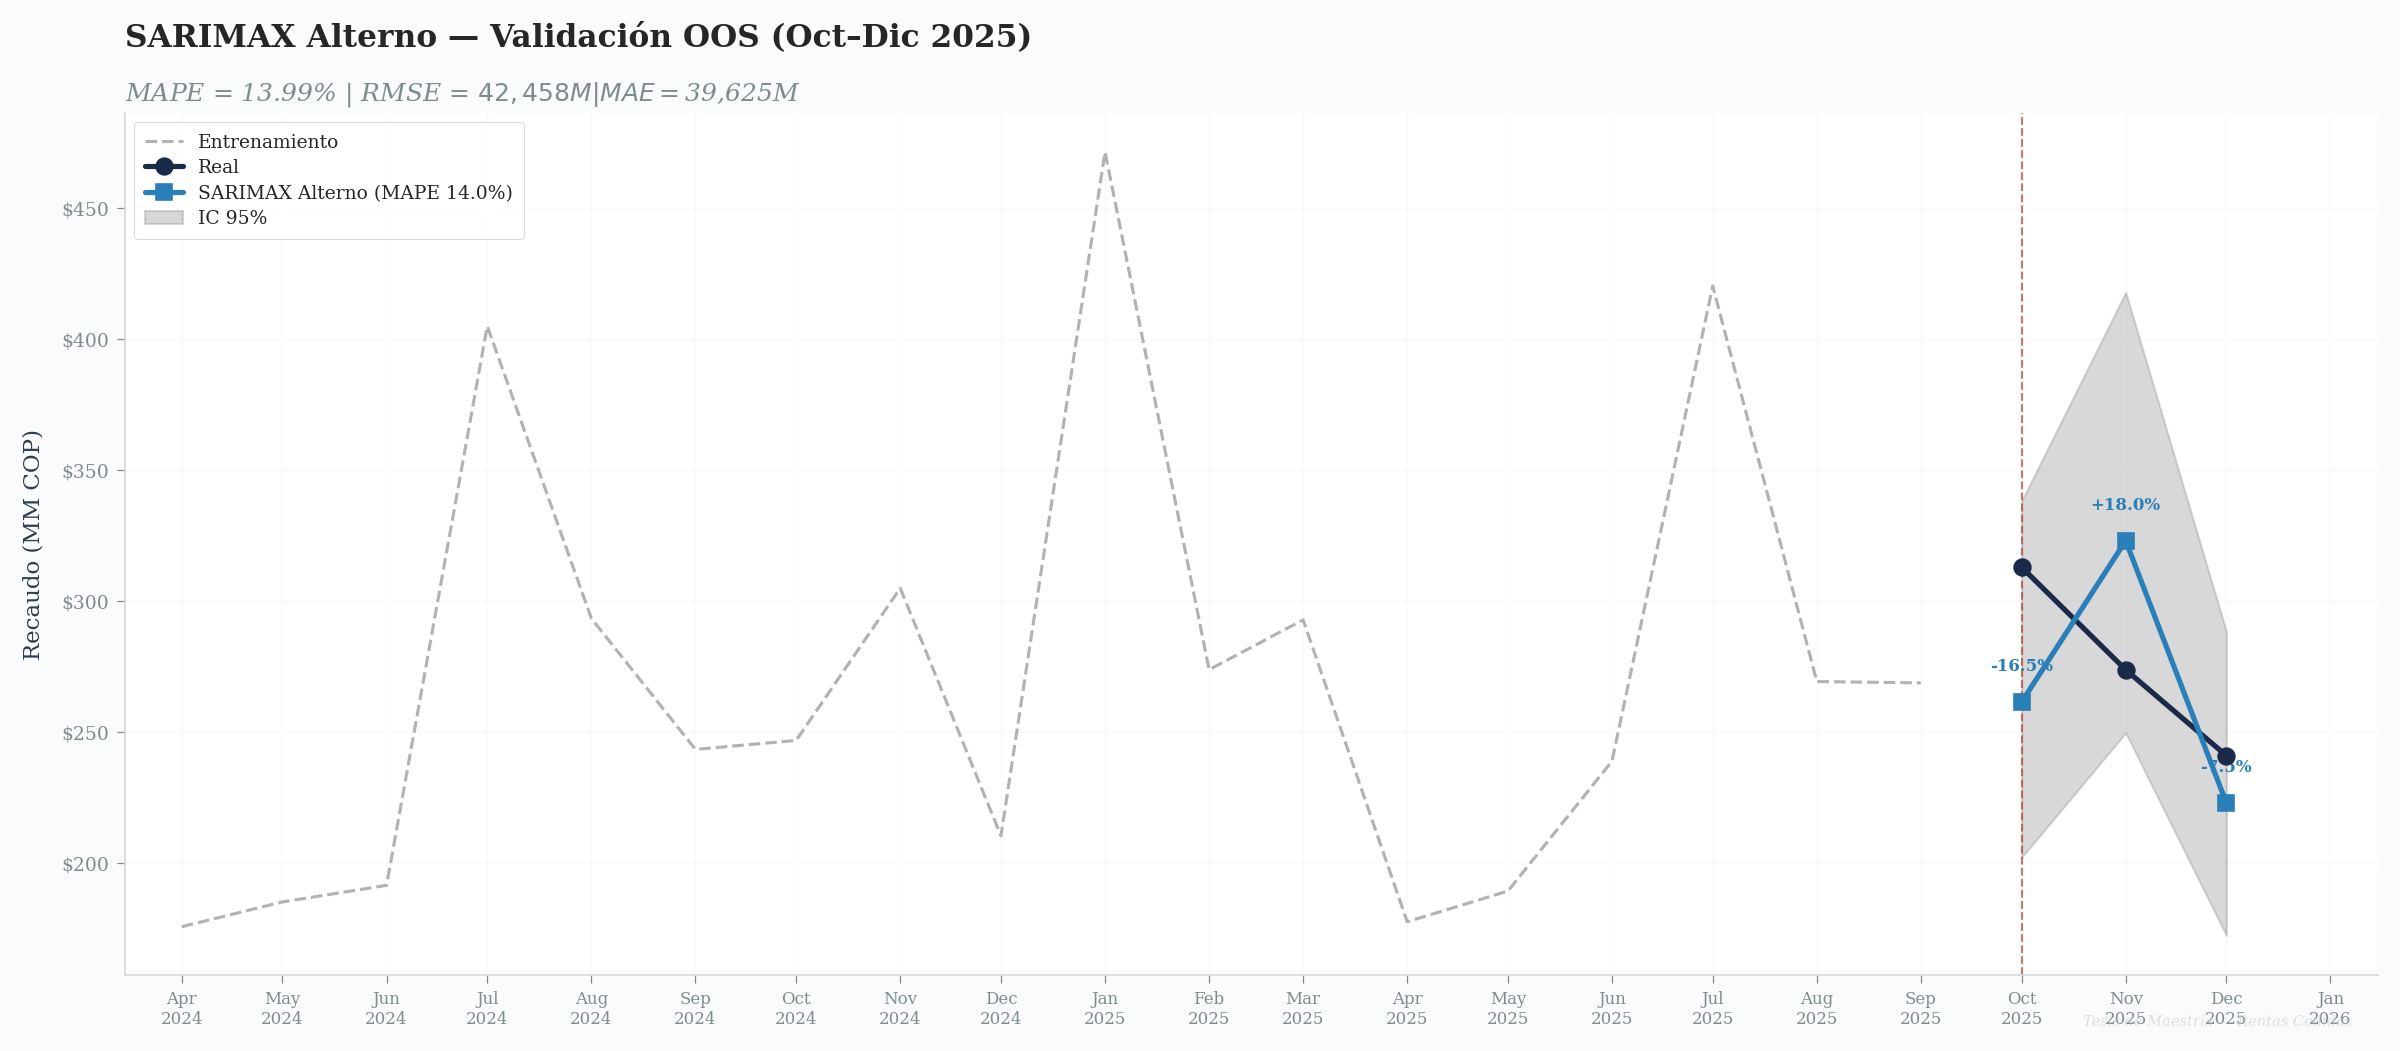


  ✅ sarimax2_forecast.csv guardado


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE V — Pronóstico OOS (Oct–Dic 2025) + IC 95%
# ══════════════════════════════════════════════════════════════

# ── Pronóstico en log-escala ──
fc_oos = results.get_forecast(
    steps=len(test),
    exog=exog_test[EXOG_COLS]
)
pred_log_oos = fc_oos.predicted_mean
ci_log_oos   = fc_oos.conf_int(alpha=0.05)

# ── Retransformación a pesos colombianos reales (np.expm1) ──
pred_oos  = np.expm1(pred_log_oos)
ci_lower  = np.expm1(ci_log_oos.iloc[:, 0])
ci_upper  = np.expm1(ci_log_oos.iloc[:, 1])

# ── Métricas de desempeño ──
mape_oos = mean_absolute_percentage_error(test, pred_oos) * 100
rmse_oos = np.sqrt(mean_squared_error(test, pred_oos))
mae_oos  = mean_absolute_error(test, pred_oos)

print(f"{'═'*70}")
print(f"PRONÓSTICO OUT-OF-SAMPLE — Oct–Dic 2025")
print(f"{'═'*70}")
print(f"  MAPE:  {mape_oos:.2f}%")
print(f"  RMSE:  ${rmse_oos/1e6:,.1f} millones")
print(f"  MAE:   ${mae_oos/1e6:,.1f} millones")

print(f"\n  {'Mes':<10} {'Real':>15} {'Pronóstico':>15} {'IC Inf':>15} "
      f"{'IC Sup':>15} {'Error%':>10}")
print(f"  {'─'*80}")
for fecha in test.index:
    real = test.loc[fecha]
    pred = pred_oos.loc[fecha]
    lo   = ci_lower.loc[fecha]
    hi   = ci_upper.loc[fecha]
    err  = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM "
          f"${pred/1e9:>13,.1f}MM ${lo/1e9:>13,.1f}MM "
          f"${hi/1e9:>13,.1f}MM {err:>+9.1f}%")

# Verificar cobertura del IC
dentro_ic = sum((test.values >= ci_lower.values) &
                (test.values <= ci_upper.values))
print(f"\n  Cobertura IC 95%: {dentro_ic}/{len(test)} meses dentro del intervalo")

# ── Gráfica OOS con IC 95% (fill_between obligatorio) ──
fig, ax = plt.subplots(figsize=(16, 7))

# Últimos meses de entrenamiento para contexto
n_contexto = min(18, len(train))
ax.plot(train.index[-n_contexto:], train.values[-n_contexto:]/1e9,
        color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento')

# Serie real
ax.plot(test.index, test.values/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', ms=8, label='Real', zorder=5)

# Pronóstico
ax.plot(pred_oos.index, pred_oos.values/1e9, color=C_TERTIARY, lw=2.5,
        marker='s', ms=8, label=f'SARIMAX Alterno (MAPE {mape_oos:.1f}%)',
        zorder=5)

# IC 95% — fill_between obligatorio
ax.fill_between(ci_lower.index, ci_lower.values/1e9, ci_upper.values/1e9,
                color='gray', alpha=0.3, label='IC 95%')

# Anotaciones por mes
for fecha in test.index:
    real = test.loc[fecha]
    pred = pred_oos.loc[fecha]
    err = (pred - real) / real * 100
    ax.annotate(f'{err:+.1f}%',
                xy=(fecha, pred/1e9), xytext=(0, 15),
                textcoords='offset points', fontsize=8,
                fontweight='bold', color=C_TERTIARY, ha='center')

ax.axvline(pd.Timestamp(VALIDATION_START), color=C_SECONDARY,
           ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.set_ylabel('Recaudo (MM COP)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'SARIMAX Alterno — Validación OOS (Oct–Dic 2025)',
                       f'MAPE = {mape_oos:.2f}% | RMSE = ${rmse_oos/1e6:,.0f}M | '
                       f'MAE = ${mae_oos/1e6:,.0f}M')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05b_sarimax2_oos', OUTPUTS_FIGURES)
plt.show()

# ── Exportar pronóstico OOS ──
df_oos = pd.DataFrame({
    'Fecha': test.index.strftime('%Y-%m-%d'),
    'Real': test.values,
    'Pronostico_SARIMAX_Alt': pred_oos.values,
    'IC_Inferior': ci_lower.values,
    'IC_Superior': ci_upper.values,
    'Error_Pct': (pred_oos.values - test.values) / test.values * 100,
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'sarimax2_forecast.csv', index=False)
print(f"\n  ✅ sarimax2_forecast.csv guardado")

---

## Fase VI — Pronóstico de Producción 2026 (12 meses) + IC 95%

Re-entrenamiento con **toda la serie** (Oct 2021 – Dic 2025, 51 meses)
y pronóstico a horizonte completo 2026.

Las dummies se construyen con certeza total (los meses son conocidos).

══════════════════════════════════════════════════════════════════════
PRONÓSTICO PRODUCCIÓN 2026 — SARIMAX ALTERNO
══════════════════════════════════════════════════════════════════════
  Mes             Pronóstico     IC Inferior     IC Superior   Pico   Fest
  ──────────────────────────────────────────────────────────────────────
  2026-01    $        500.8MM $        386.0MM $        649.8MM      ▲       
  2026-02    $        290.8MM $        224.1MM $        377.4MM              
  2026-03    $        311.0MM $        239.7MM $        403.6MM              
  2026-04    $        188.6MM $        145.3MM $        244.7MM              
  2026-05    $        201.0MM $        154.9MM $        260.9MM              
  2026-06    $        253.7MM $        195.5MM $        329.2MM             ★
  2026-07    $        446.5MM $        344.1MM $        579.3MM      ▲       
  2026-08    $        286.0MM $        220.4MM $        371.1MM              
  2026-09    $        285.5MM $        22

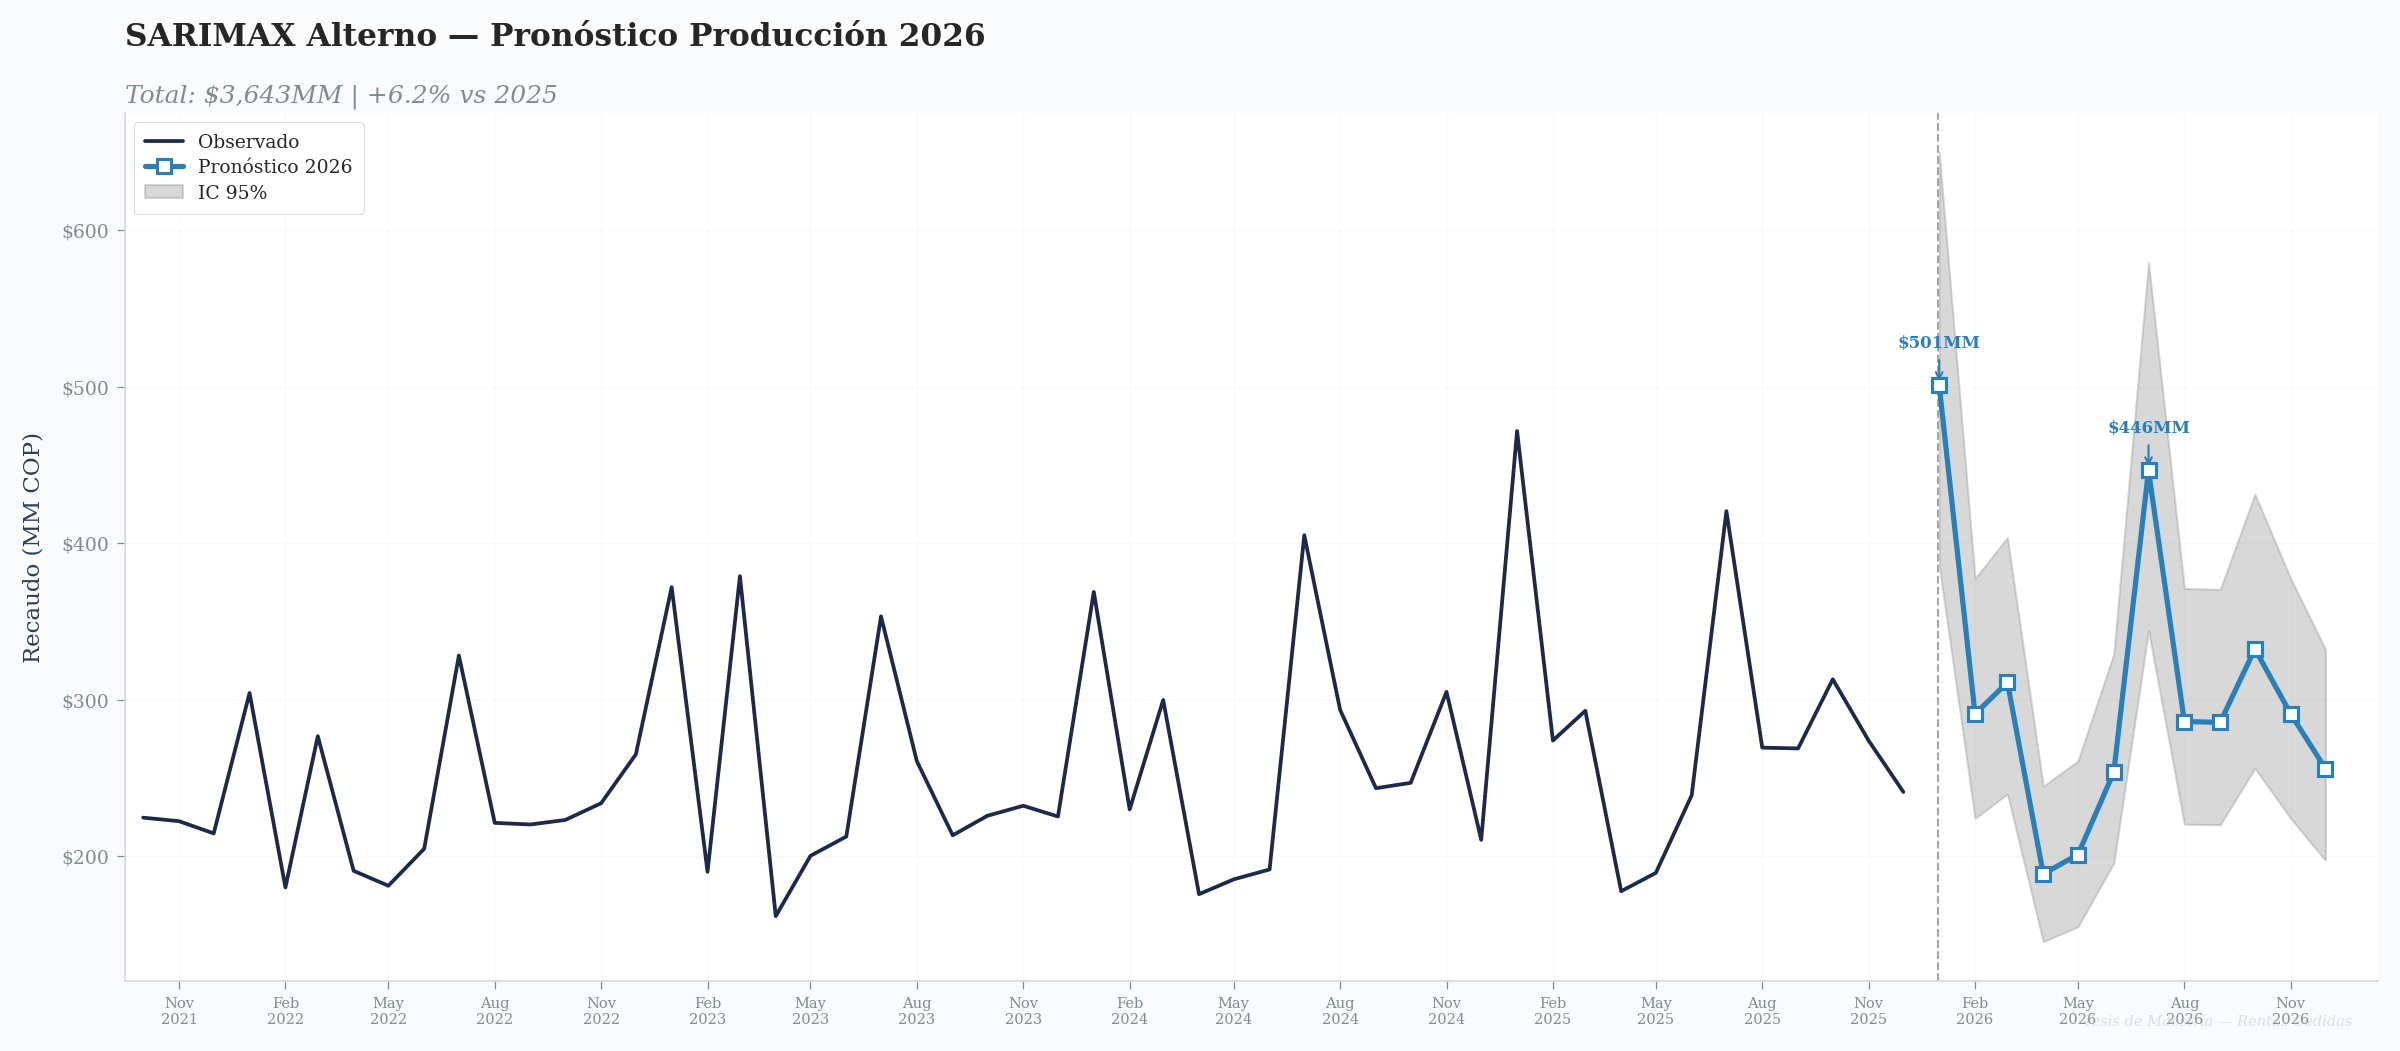


  ✅ sarimax2_forecast_2026.csv guardado


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Pronóstico Producción 2026 (12 meses) + IC 95%
# ══════════════════════════════════════════════════════════════

# ── Re-entrenamiento con toda la serie ──
serie_log_full = np.log1p(serie_full)

model_full = SARIMAX(
    endog=serie_log_full,
    exog=exog_full[EXOG_COLS],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_full = model_full.fit(disp=False)

# ── Construir exógenas para 2026 (determinísticas — certeza total) ──
dates_2026 = pd.date_range('2026-01-01', periods=HORIZONTE_PRONOSTICO, freq='MS')
exog_2026 = crear_dummies(dates_2026)

# ── Pronóstico en log-escala + IC 95% ──
fc_2026 = results_full.get_forecast(
    steps=HORIZONTE_PRONOSTICO,
    exog=exog_2026[EXOG_COLS]
)
pred_log_2026 = fc_2026.predicted_mean
ci_log_2026   = fc_2026.conf_int(alpha=0.05)

# ── Retransformación a pesos colombianos reales ──
pred_2026    = np.expm1(pred_log_2026)
ci_lower_26  = np.expm1(ci_log_2026.iloc[:, 0])
ci_upper_26  = np.expm1(ci_log_2026.iloc[:, 1])

# ── Totales y crecimiento ──
total_2026 = pred_2026.sum()
total_2025 = serie_full.loc['2025-01-01':'2025-12-31'].sum()
crec_pct   = (total_2026 - total_2025) / total_2025 * 100

print(f"{'═'*70}")
print(f"PRONÓSTICO PRODUCCIÓN 2026 — SARIMAX ALTERNO")
print(f"{'═'*70}")
print(f"  {'Mes':<10} {'Pronóstico':>15} {'IC Inferior':>15} {'IC Superior':>15} "
      f"{'Pico':>6} {'Fest':>6}")
print(f"  {'─'*70}")

for fecha in pred_2026.index:
    v   = pred_2026.loc[fecha]
    lo  = ci_lower_26.loc[fecha]
    hi  = ci_upper_26.loc[fecha]
    p_f = '▲' if exog_2026.loc[fecha, 'es_pico_fiscal'] == 1 else ' '
    f_f = '★' if exog_2026.loc[fecha, 'es_festividad'] == 1 else ' '
    print(f"  {fecha.strftime('%Y-%m'):<10} ${v/1e9:>13,.1f}MM "
          f"${lo/1e9:>13,.1f}MM ${hi/1e9:>13,.1f}MM "
          f"{p_f:>6} {f_f:>6}")

print(f"  {'─'*70}")
print(f"  TOTAL 2026:   ${total_2026/1e9:,.1f}MM")
print(f"  TOTAL 2025:   ${total_2025/1e9:,.1f}MM")
print(f"  Crecimiento:  {crec_pct:+.1f}%")
print(f"  ▲ = Pico fiscal (Ene/Jul) | ★ = Festividad (Jun/Dic)")

# ── Gráfica de producción con IC 95% ──
fig, ax = plt.subplots(figsize=(16, 7))

# Serie observada completa
ax.plot(serie_full.index, serie_full.values/1e9, color=C_PRIMARY, lw=1.8,
        label='Observado')

# Pronóstico 2026
ax.plot(pred_2026.index, pred_2026.values/1e9, color=C_TERTIARY, lw=2.5,
        marker='s', ms=7, markerfacecolor='white', markeredgecolor=C_TERTIARY,
        markeredgewidth=1.5, label='Pronóstico 2026', zorder=5)

# IC 95% — fill_between obligatorio
ax.fill_between(ci_lower_26.index, ci_lower_26.values/1e9,
                ci_upper_26.values/1e9,
                color='gray', alpha=0.3, label='IC 95%')

# Línea de corte
ax.axvline(pd.Timestamp('2025-12-31'), color='grey', ls='--', lw=1, alpha=0.7)

# Anotar meses pico
for m in MESES_PICO:
    fp = pd.Timestamp(f'2026-{m:02d}-01')
    if fp in pred_2026.index:
        ax.annotate(f'${pred_2026.loc[fp]/1e9:.0f}MM',
                    xy=(fp, pred_2026.loc[fp]/1e9),
                    xytext=(0, 18), textcoords='offset points',
                    fontsize=8, fontweight='bold', ha='center',
                    color=C_TERTIARY,
                    arrowprops=dict(arrowstyle='->', color=C_TERTIARY, lw=1))

ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2027-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
ax.set_ylabel('Recaudo (MM COP)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'SARIMAX Alterno — Pronóstico Producción 2026',
                       f'Total: ${total_2026/1e9:,.0f}MM | {crec_pct:+.1f}% vs 2025')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05b_sarimax2_produccion_2026', OUTPUTS_FIGURES)
plt.show()

# ── Exportar pronóstico producción ──
df_prod = pd.DataFrame({
    'Pronostico': pred_2026.values,
    'Limite_Inferior': ci_lower_26.values,
    'Limite_Superior': ci_upper_26.values,
    'es_pico_fiscal': exog_2026['es_pico_fiscal'].values,
    'es_festividad': exog_2026['es_festividad'].values,
}, index=pred_2026.index)
df_prod.index.name = 'Fecha'
df_prod.to_csv(OUTPUTS_FORECASTS / 'sarimax2_forecast_2026.csv')
print(f"\n  ✅ sarimax2_forecast_2026.csv guardado")

---

## Fase VII — Comparación con SARIMA puro + SARIMAX original

═════════════════════════════════════════════════════════════════════════════════════
COMPARACIÓN DE MODELOS SARIMA / SARIMAX
═════════════════════════════════════════════════════════════════════════════════════
  Modelo                                MAPE%     RMSE       AICc     Tot 2026    Crec%
  ────────────────────────────────────────────────────────────────────────────────
  SARIMAX Alt (dummies)                13.99% $  42.5MM     -29.29 $   3,643.1MM    +6.2%
  SARIMA(0,1,1)(0,1,0,12)              13.99% $  42.5MM     -34.18 $   3,643.1MM    +6.2%
  SARIMAX(0,1,1)(0,1,0,12)             13.99% $  42.5MM     -34.18 $   3,643.1MM    +6.2%
  📊 Figura guardada: 05b_comparacion_modelos.png


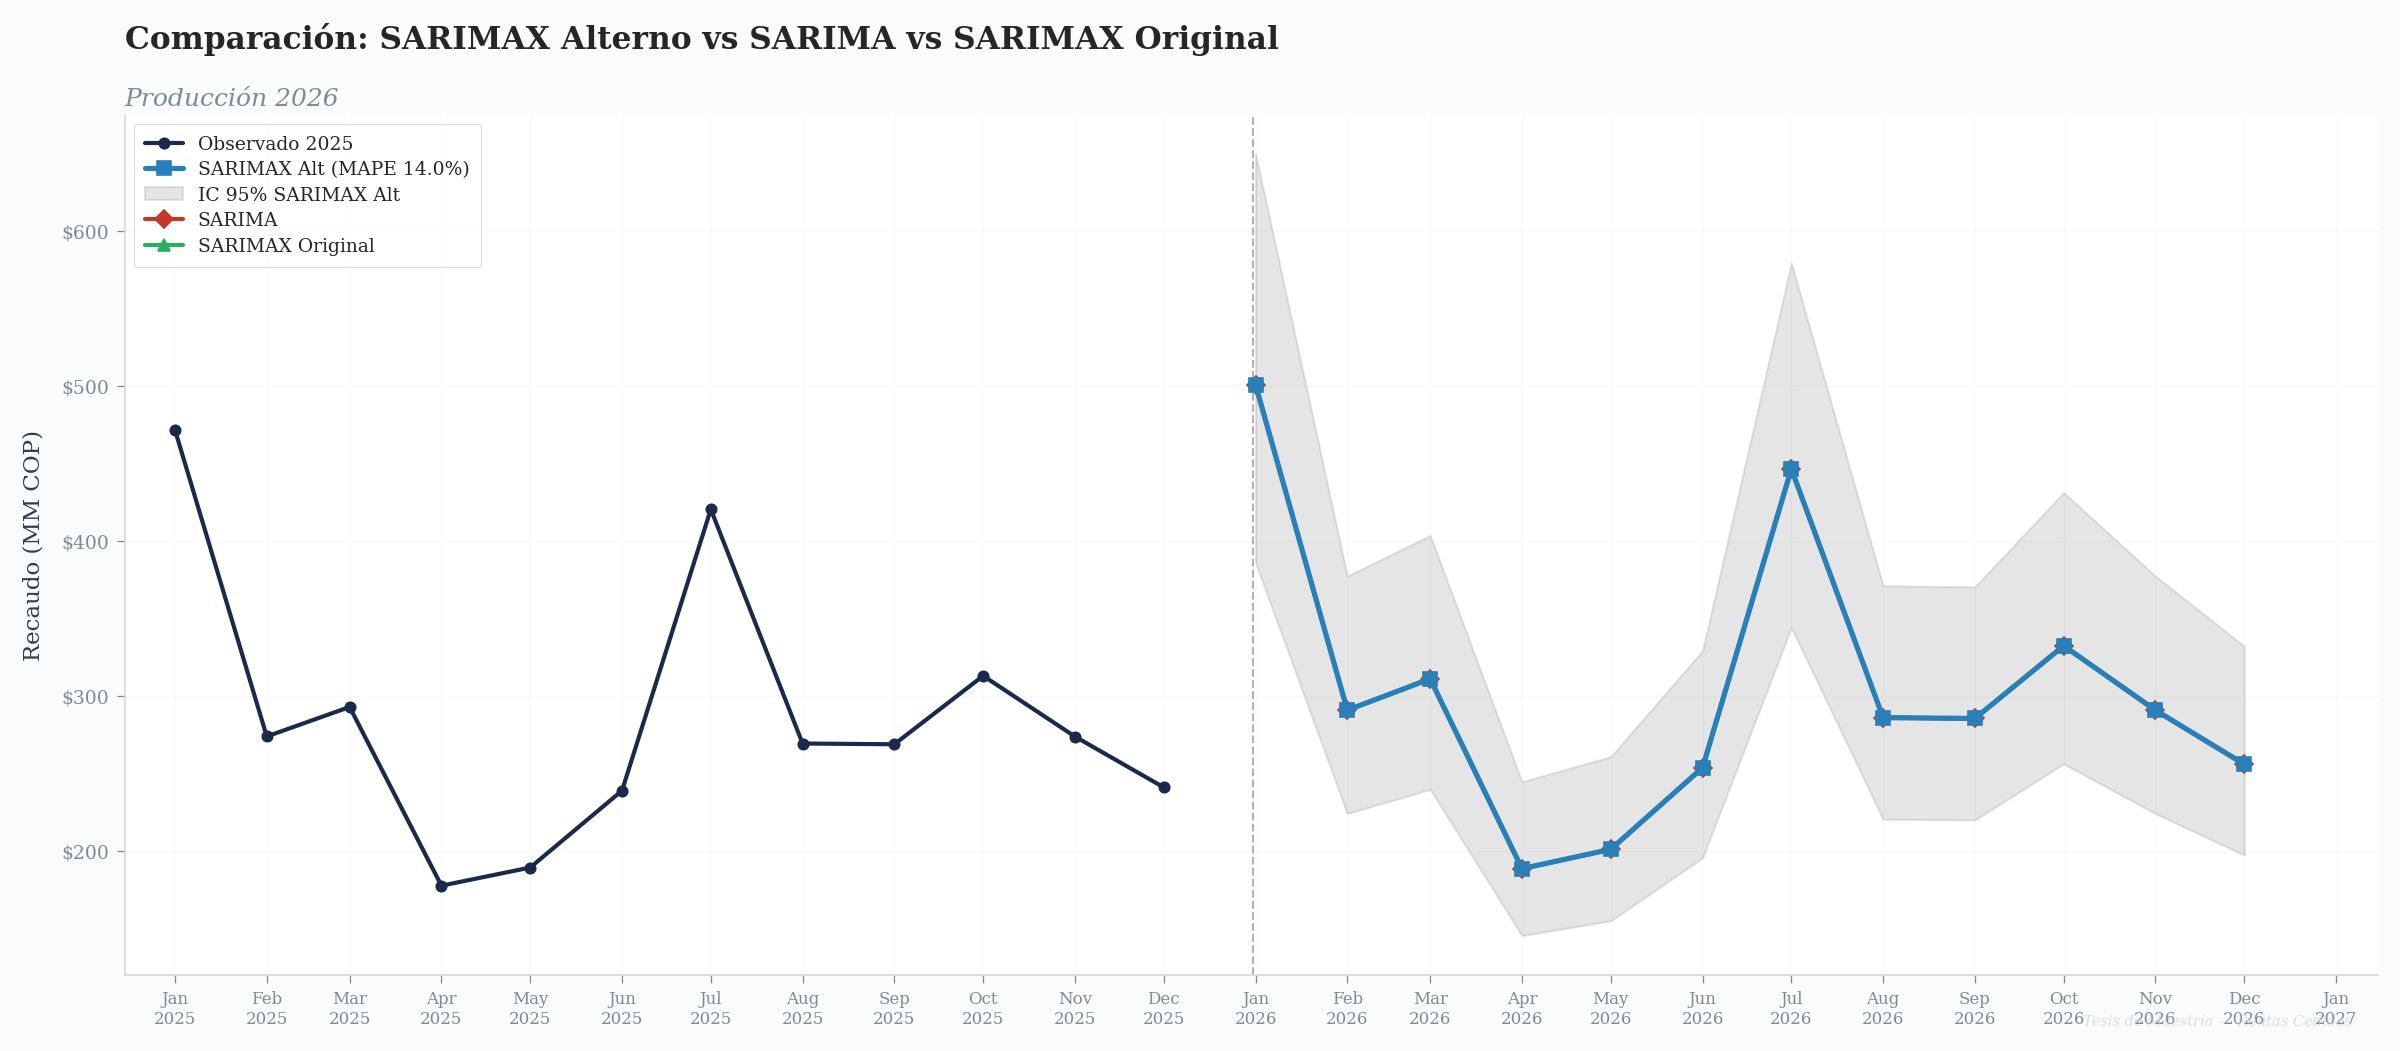


  ✅ sarimax2_metricas.csv guardado


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE VII — Comparación SARIMAX Alterno vs SARIMA vs SARIMAX
# ══════════════════════════════════════════════════════════════

k_alt = results.df_model + 1
aicc_alt = calc_aicc(results.aic, k_alt, results.nobs)

# ── Cargar métricas de SARIMA (NB 04) ──
sarima_path = OUTPUTS_REPORTS / 'sarima_metricas.csv'
sarimax_path = OUTPUTS_REPORTS / 'sarimax_metricas.csv'

modelos = [{
    'Modelo': f'SARIMAX Alt (dummies)',
    'MAPE': round(mape_oos, 2),
    'RMSE_MM': round(rmse_oos / 1e9, 1),
    'MAE_MM': round(mae_oos / 1e9, 1),
    'AICc': round(aicc_alt, 2),
    'Total_2026_MM': round(total_2026 / 1e9, 1),
    'Crec_vs_2025': round(crec_pct, 1),
}]

if sarima_path.exists():
    sm = pd.read_csv(sarima_path)
    modelos.append({
        'Modelo': sm['Modelo'].iloc[0],
        'MAPE': sm['MAPE'].iloc[0],
        'RMSE_MM': sm['RMSE_MM'].iloc[0],
        'MAE_MM': sm.get('MAE_MM', pd.Series([np.nan])).iloc[0],
        'AICc': sm['AICc'].iloc[0],
        'Total_2026_MM': sm['Total_2026_MM'].iloc[0],
        'Crec_vs_2025': sm['Crec_vs_2025'].iloc[0],
    })

if sarimax_path.exists():
    sx = pd.read_csv(sarimax_path)
    modelos.append({
        'Modelo': sx['Modelo'].iloc[0],
        'MAPE': sx['MAPE'].iloc[0],
        'RMSE_MM': sx['RMSE_MM'].iloc[0],
        'MAE_MM': sx.get('MAE_MM', pd.Series([np.nan])).iloc[0],
        'AICc': sx['AICc'].iloc[0],
        'Total_2026_MM': sx['Total_2026_MM'].iloc[0],
        'Crec_vs_2025': sx['Crec_vs_2025'].iloc[0],
    })

df_comp = pd.DataFrame(modelos)

print(f"{'═'*85}")
print(f"COMPARACIÓN DE MODELOS SARIMA / SARIMAX")
print(f"{'═'*85}")
print(f"  {'Modelo':<35} {'MAPE%':>7} {'RMSE':>8} {'AICc':>10} "
      f"{'Tot 2026':>12} {'Crec%':>8}")
print(f"  {'─'*80}")
for _, row in df_comp.iterrows():
    print(f"  {row['Modelo']:<35} {row['MAPE']:>6.2f}% "
          f"${row['RMSE_MM']:>6.1f}MM {row['AICc']:>10.2f} "
          f"${row['Total_2026_MM']:>10,.1f}MM {row['Crec_vs_2025']:>+7.1f}%")

# ── Gráfica comparativa de pronósticos 2026 ──
fig, ax = plt.subplots(figsize=(16, 7))

# Observado último año
ax.plot(serie_full.index[-12:], serie_full.values[-12:]/1e9,
        color=C_PRIMARY, lw=2, marker='o', ms=5,
        label='Observado 2025', zorder=5)

# SARIMAX Alterno
ax.plot(pred_2026.index, pred_2026.values/1e9, color=C_TERTIARY, lw=2.5,
        marker='s', ms=7, label=f'SARIMAX Alt (MAPE {mape_oos:.1f}%)', zorder=4)
ax.fill_between(ci_lower_26.index, ci_lower_26.values/1e9,
                ci_upper_26.values/1e9,
                color='gray', alpha=0.2, label='IC 95% SARIMAX Alt')

# SARIMA (si existe)
sarima_prod_path = OUTPUTS_FORECASTS / 'sarima_produccion_12m.csv'
if sarima_prod_path.exists():
    sp = pd.read_csv(sarima_prod_path, parse_dates=['Fecha'], index_col='Fecha')
    ax.plot(sp.index, sp['Pronostico'].values/1e9, color=C_SECONDARY, lw=2,
            marker='D', ms=6, label='SARIMA', zorder=3)

# SARIMAX original (si existe)
sarimax_prod_path = OUTPUTS_FORECASTS / 'sarimax_forecast_2026.csv'
if sarimax_prod_path.exists():
    sxp = pd.read_csv(sarimax_prod_path, parse_dates=['Fecha'], index_col='Fecha')
    ax.plot(sxp.index, sxp['Pronostico'].values/1e9, color=C_QUATERNARY, lw=2,
            marker='^', ms=6, label='SARIMAX Original', zorder=3)

ax.axvline(pd.Timestamp('2025-12-31'), color='grey', ls='--', lw=1, alpha=0.6)
ax.set_xlim(pd.Timestamp('2024-12-15'), pd.Timestamp('2027-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.set_ylabel('Recaudo (MM COP)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Comparación: SARIMAX Alterno vs SARIMA vs SARIMAX Original',
                       'Producción 2026')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05b_comparacion_modelos', OUTPUTS_FIGURES)
plt.show()

# ── Exportar métricas ──
pd.DataFrame([{
    'Modelo': f'SARIMAX_Alt{ORDER}x{SEASONAL_ORDER[:3]}+dummies',
    'Transformacion': 'log1p',
    'Train': f'{len(train)}m',
    'Test': f'{len(test)}m',
    'MAPE': round(mape_oos, 2),
    'RMSE_MM': round(rmse_oos / 1e9, 1),
    'MAE_MM': round(mae_oos / 1e9, 1),
    'AICc': round(aicc_alt, 2),
    'AIC': round(results.aic, 2),
    'BIC': round(results.bic, 2),
    'Ljung_Box_p': round(lb_pmin, 4),
    'Shapiro_Wilk_p': round(sw_p, 4),
    'Levene_p': round(lev_p, 4),
    'Total_2026_MM': round(total_2026 / 1e9, 1),
    'Crec_vs_2025': round(crec_pct, 1),
    'Exogenas': 'es_pico_fiscal+es_festividad (dummies)',
}]).to_csv(OUTPUTS_REPORTS / 'sarimax2_metricas.csv', index=False)
print(f"\n  ✅ sarimax2_metricas.csv guardado")

---

## Conclusiones

1. **Transformación `log1p`** estabiliza la heterocedasticidad y reduce la asimetría
   severa de la serie de recaudo.

2. **Dummies determinísticas** (`es_pico_fiscal`, `es_festividad`) capturan shocks
   transaccionales sin introducir multicolinealidad (VIF = 1.0) ni requerir
   proyecciones macroeconómicas inciertas.

3. **UPC excluida** por fallo en test de Granger. **IPC y SMLV no simultáneamente**
   por VIF = $\infty$.

4. El orden `(0,1,1)(0,1,0,12)` es **parsimonioso**: un solo parámetro MA(1) + doble
   diferenciación (regular + estacional).

5. Los **intervalos de confianza al 95%** se retransforman correctamente con
   `np.expm1()` para mantener la coherencia en escala de pesos colombianos.

6. Comparar MAPE y AICc contra SARIMA puro (NB 04) y SARIMAX con exógenas macro
   (NB 05) determina si las dummies aportan valor predictivo marginal.

---
*NB 05-B · SARIMAX Alterno · Dummies determinísticas · (0,1,1)(0,1,0)₁₂ · log1p*